In [ ]:
%pip install python-dotenv
%pip install roboflow
%pip install supervision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 83.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 96.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [ ]:
from google.colab import userdata
userdata.get('TEST')

'test'

In [ ]:
# from dotenv import load_dotenv

# load_dotenv()

from roboflow import Roboflow

# if google colab run:
from google.colab import userdata
ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace("caretech-qnw0y").project("v1-caretech-combined-dataset")
dataset = project.version(1).download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to [V1]-CareTech-Combined-Dataset-1 in yolov8:: 100%|██████████| 58572/58572 [00:06<00:00, 9333.61it/s] 


In [ ]:
!mv "/content/[V1]-CareTech-Combined-Dataset-1" "/content/V1-CareTech-Combined-Dataset-1"
!rm -rf "/content/[V1]-CareTech-Combined-Dataset-1"

In [ ]:
%pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 69.7 MB/s eta 0:00:00


In [ ]:
# script to split training dataset
import os
import shutil
from pathlib import Path
import supervision as sv


# creates a new folder with just the images and labels
dir = Path('/content/V1-CareTech-Combined-Dataset-1')
unified_dir = Path('/content/all')
split_path = Path('/content/split')

new_img_dir = unified_dir / 'images'
new_label_dir = unified_dir / 'labels'

new_img_dir.mkdir(parents=True, exist_ok=True)
new_label_dir.mkdir(parents=True, exist_ok=True)

# write to a flattened folder
for file in dir.rglob('*.jpg'):
    shutil.copy(file, new_img_dir)

exclude = ['README.roboflow.txt', 'README.dataset.txt']
for file in dir.rglob('*.txt'):
    if str(file.name) in exclude:
        continue
    shutil.copy(file, new_label_dir)


In [ ]:
# # script to split training dataset
# import os
# import shutil
# from pathlib import Path
# import supervision as sv

# # locate dataset root robustly
# dataset_root = Path('datasets/Food-Dataset-1')
# # candidates = [Path('lahari_himal/Food-Dataset-1'), Path('Food-Dataset-1')]
# # for c in candidates:
# #     if (c / 'data.yaml').exists():
# #         dataset_root = c.resolve()
# #         break
# # if dataset_root is None:
# #     matches = list(Path.cwd().rglob('Food-Dataset-1/data.yaml'))
# #     if matches:
# #         dataset_root = matches[0].parent.resolve()
# #     else:
# #         raise FileNotFoundError("Could not find Food-Dataset-1/data.yaml in workspace")

# # creates a new folder with just the images and labels
# dir = dataset_root
# unified_dir = dir.parent / 'all'
# split_path = dir.parent / 'split'

# new_img_dir = unified_dir / 'images'
# new_label_dir = unified_dir / 'labels'

# new_img_dir.mkdir(parents=True, exist_ok=True)
# new_label_dir.mkdir(parents=True, exist_ok=True)

# # write to a flattened folder
# for file in dir.rglob('*.jpg'):
#     shutil.copy(file, new_img_dir)

# exclude = ['README.roboflow.txt', 'README.dataset.txt']
# for file in dir.rglob('*.txt'):
#     if str(file.name) in exclude:
#         continue
#     shutil.copy(file, new_label_dir)


In [ ]:
!rm -rf '/content/[V1]-CareTech-Combined-Dataset-1'

In [ ]:
# this loads a DetectionDataset object
ds = sv.DetectionDataset.from_yolo(
    images_directory_path=str(new_img_dir),
    annotations_directory_path=str(new_label_dir),
    data_yaml_path=str(dir / 'data.yaml')
)

print(ds.classes)

seed = 1
# we can split this dataset deterministically
train_ds, rest_ds = ds.split(split_ratio=0.8, random_state=seed, shuffle=True)
test_ds, val_ds = rest_ds.split(split_ratio=0.5, random_state=seed, shuffle=True)

# save new datasets in yolo format
train_ds.as_yolo(
    images_directory_path=str(split_path / 'train' / 'images'),
    annotations_directory_path=str(split_path / 'train' / 'labels'),
    data_yaml_path=str(split_path / 'train' / 'data.yaml')
)
test_ds.as_yolo(
    images_directory_path=str(split_path / 'test' / 'images'),
    annotations_directory_path=str(split_path / 'test' / 'labels'),
    data_yaml_path=str(split_path / 'test' / 'data.yaml')
)
val_ds.as_yolo(
    images_directory_path=str(split_path / 'valid' / 'images'),
    annotations_directory_path=str(split_path / 'valid' / 'labels'),
    data_yaml_path=str(split_path / 'valid' / 'data.yaml')
)

# write the manifest files
def write_manifest(ds: sv.DetectionDataset, split: str, output_path: Path):
  with open(output_path, "w") as f:
    for img_path, _, _ in ds:
      f.write(f"{str(Path(img_path).name)}\n")

  print(f"Wrote to {output_path}")

write_manifest(train_ds, "train", Path(split_path) / "train.txt")
write_manifest(test_ds, "test", Path(split_path) / "test.txt")
write_manifest(val_ds, "valid", Path(split_path) / "valid.txt")

['adobo', 'almond-jelly', 'apple', 'apple-pie', 'ayam-bakar', 'ayam-goreng', 'babi-guling', 'bagel', 'bak-kut-teh', 'baked-salmon', 'ball-shaped-bun-with-pork', 'barbecued-red-pork-in-sauce-with-rice', 'bean-curd-family-style', 'beef-bowl', 'beef-curry', 'beef-in-oyster-sauce', 'beef-noodle', 'beef-noodle-soup', 'bibimbap', 'boiled-chicken-and-vegetables', 'boiled-fish', 'boned-sliced-hainan-style-chicken-with-marinated-rice', 'braised-pork-meat-ball-with-napa-cabbage', 'broiled-eel-bowl', 'brownie', 'bubur-ayam', 'cabbage-roll', 'caesar-salad', 'champon', 'charcoal-boiled-pork-neck', 'chicken-cutlet', 'chicken-n-egg-on-rice', 'chicken-nugget', 'chicken-rice', 'chicken-rice-curry-with-coconut', 'chilled-noodle', 'chinese-pumpkin-pie', 'chinese-soup', 'chip-butty', 'chop-suey', 'chow-mein', 'churro', 'clear-soup', 'coconut-milk-flavored-crepes-with-shrimp-and-beef', 'coconut-milk-soup', 'cold-tofu', 'crape', 'cream-puff', 'crispy-noodles', 'croissant', 'croquette', 'crullers', 'curry-pu

Label files found: 29280
defaultdict(<class 'int'>, {'croissant': 116, 'zoni': 116, 'churro': 115, 'goya-chanpuru': 96, 'jjigae': 107, 'minced-pork-rice': 111, 'stinky-tofu': 100, 'tanmen': 109, 'okinawa-soba': 108, 'bibimbap': 113, 'tensin-noodle': 107, 'gulai': 96, 'spicy-chicken-salad': 101, 'potage': 101, 'rice-with-roast-duck': 103, 'japanese-tofu-and-vegetable-chowder': 86, 'beef-bowl': 130, 'moon-cake': 103, 'bubur-ayam': 105, 'fish-shaped-pancake-with-bean-jam': 115, 'japanese-style-pancake': 134, 'pork-belly': 105, 'cutlet-curry': 136, 'mushroom-risotto': 113, 'rice-gratin': 106, 'cream-puff': 108, 'eggplant-with-garlic-sauce': 113, 'dry-curry': 101, 'wonton-soup': 118, 'ganmodoki': 109, 'fish-ball-soup': 119, 'pork-miso-soup': 100, 'jambalaya': 107, 'beef-curry': 219, 'simmered-pork': 106, 'fried-mussel-pancakes': 101, 'sour-prawn-soup': 106, 'green-salad': 182, 'pilaf': 109, 'mozuku': 100, 'mixed-rice': 108, 'potato-salad': 118, 'pizza': 133, 'glutinous-rice-balls': 103, 'ch

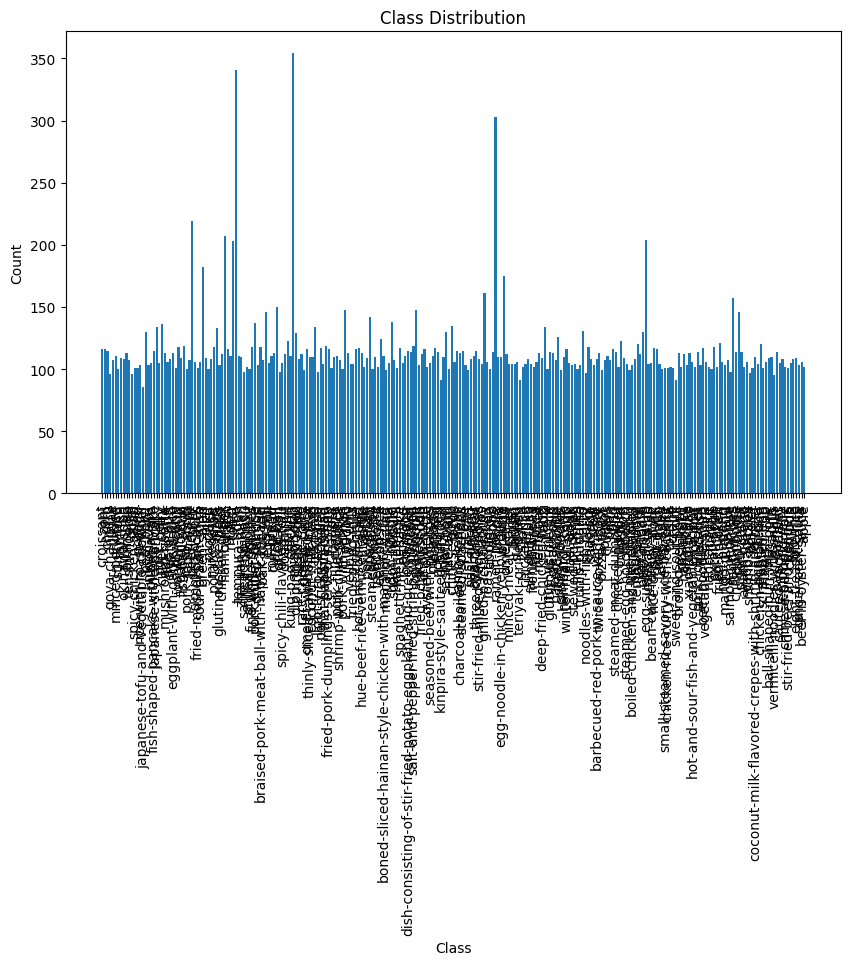

<Figure size 1000x600 with 0 Axes>

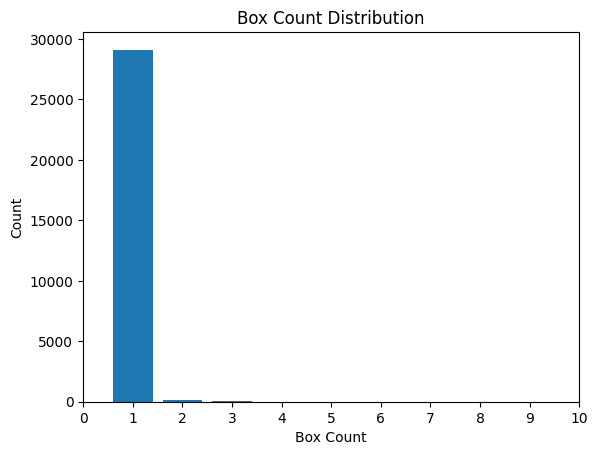

In [ ]:
# class distribution count
from collections import defaultdict
from matplotlib import pyplot as plt
from matplotlib.ticker import MaxNLocator

class_labels = { i: ds.classes[i] for i in range(len(ds.classes)) }

class_count = defaultdict(int)
box_count = defaultdict(int)
label_dir = unified_dir / 'labels'
label_files = list(label_dir.glob('*.txt'))
print(f"Label files found: {len(label_files)}")
for file in label_files:
    count = 0
    with open(file, 'r') as f:
      for line in f:
        arr = line.split()
        if not arr:
          continue

        i = int(arr[0])
        class_count[class_labels[i]] += 1
        count += 1


    box_count[count] += 1


print(class_count)

# class distribution count
# image size
# aspect ratio
# boxes per image
# noise / blur

# plot
plt.figure(figsize=(10, 6))
plt.bar(class_count.keys(), class_count.values())
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.xticks(rotation=90)
plt.show()

# plot
plt.figure(figsize=(10, 6))
ax = plt.figure().gca()
plt.bar(box_count.keys(), box_count.values())
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_xlim([0, 10])
plt.xlabel('Box Count')
plt.ylabel('Count')
plt.title('Box Count Distribution')
plt.show()

Images found: 29280


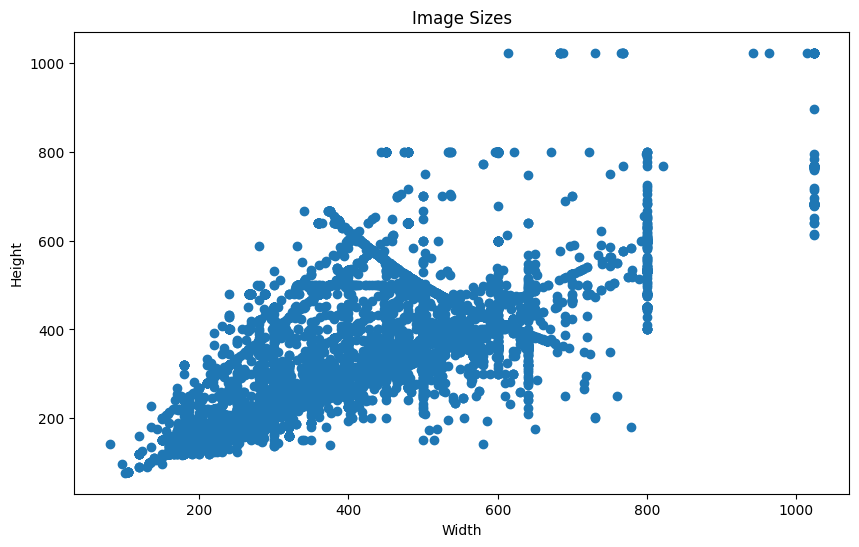

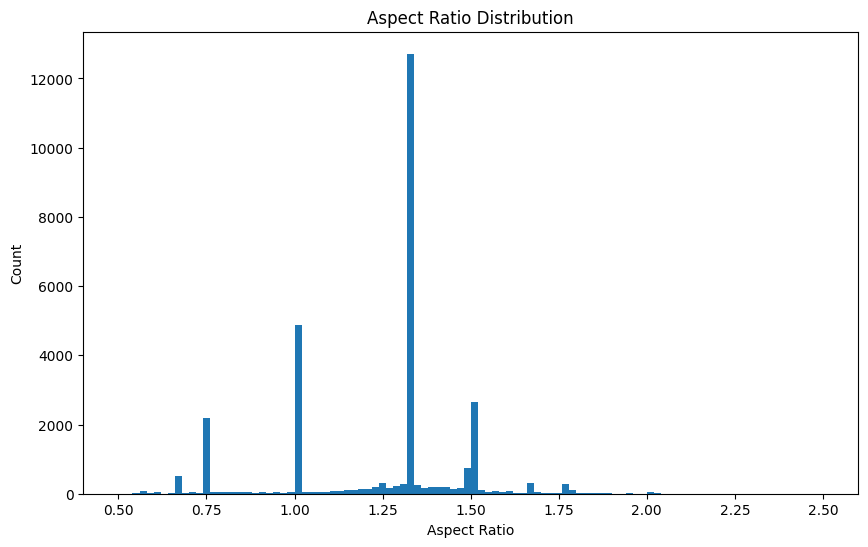

In [ ]:
from PIL import Image

# image size
sizes: list[tuple[int, int]] = [] # width x height
img_dir = unified_dir / 'images'
images = list(img_dir.glob('*.jpg'))
print(f"Images found: {len(images)}")
for img in images:
  with Image.open(img) as im:
    sizes.append(im.size)

ratios = [s[0] / s[1] for s in sizes]

# plot
plt.figure(figsize=(10, 6))
plt.scatter([s[0] for s in sizes], [s[1] for s in sizes])
plt.xlabel('Width')
plt.ylabel('Height')
plt.title('Image Sizes')
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(ratios, bins=100, range=(0.5, 2.5))
plt.xlabel('Aspect Ratio')
plt.ylabel('Count')
plt.title('Aspect Ratio Distribution')
plt.show()

In [ ]:
import glob

for root, dirs, files in os.walk("/content/split", topdown=True):
    if os.path.basename(root) == "images":
        print("IMAGES FOLDER:", root)
        imgs = glob.glob(os.path.join(root, "*.jpg"))
        print("IMAGES FOLDER:", root, "->", len(imgs))

IMAGES FOLDER: /content/split/train/images
IMAGES FOLDER: /content/split/train/images -> 23424
IMAGES FOLDER: /content/split/valid/images
IMAGES FOLDER: /content/split/valid/images -> 2928
IMAGES FOLDER: /content/split/test/images
IMAGES FOLDER: /content/split/test/images -> 2928


In [ ]:

%pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 57.6 MB/s eta 0:00:00


In [ ]:
from pathlib import Path
from collections import Counter

def count_images_per_class(labels_dir, class_names):
    """Count how many images contain each class (not total boxes)"""
    labels_dir = Path(labels_dir)
    image_count_per_class = Counter()

    for lbl_file in labels_dir.glob('*.txt'):
        with lbl_file.open() as f:
            # Get unique classes in this image
            classes_in_image = set(int(line.split()[0]) for line in f if line.strip())
        for cls_id in classes_in_image:
            image_count_per_class[cls_id] += 1

    print(f"\n📊 Class distribution in {labels_dir.parent.name}:")
    print("-" * 60)
    for cls_id in range(len(class_names)):
        count = image_count_per_class.get(cls_id, 0)
        print(f"{cls_id:2d} {class_names[cls_id]:30s}: {count:4d} images")
    print("-" * 60)
    return image_count_per_class

# Use existing split_path variable from earlier cells
train_labels = split_path / 'train' / 'labels'
valid_labels = split_path / 'valid' / 'labels'
test_labels = split_path / 'test' / 'labels'

# Load class names (already available in ds.classes)
class_names = ds.classes

# Count distribution
train_counts = count_images_per_class(train_labels, class_names)
valid_counts = count_images_per_class(valid_labels, class_names)
test_counts = count_images_per_class(test_labels, class_names)


📊 Class distribution in train:
------------------------------------------------------------
 0 adobo                         :   79 images
 1 almond-jelly                  :   84 images
 2 apple                         :   34 images
 3 apple-pie                     :   80 images
 4 ayam-bakar                    :   95 images
 5 ayam-goreng                   :   82 images
 6 babi-guling                   :   77 images
 7 bagel                         :   86 images
 8 bak-kut-teh                   :   84 images
 9 baked-salmon                  :   85 images
10 ball-shaped-bun-with-pork     :   88 images
11 barbecued-red-pork-in-sauce-with-rice:   90 images
12 bean-curd-family-style        :   86 images
13 beef-bowl                     :   96 images
14 beef-curry                    :  175 images
15 beef-in-oyster-sauce          :   93 images
16 beef-noodle                   :  109 images
17 beef-noodle-soup              :   96 images
18 bibimbap                      :   80 images
19 boil

In [ ]:
import yaml

# Use existing split_path from earlier cells
data_yaml_content = {
    'path': str(split_path.resolve()),  # dataset root
    'train': 'train/images',
    'val': 'valid/images',
    'test': 'test/images',
    'nc': len(ds.classes),
    'names': ds.classes
}

# Write unified data.yaml
unified_yaml_path = split_path / 'data.yaml'
with open(unified_yaml_path, 'w') as f:
    yaml.dump(data_yaml_content, f, sort_keys=False)

print(f"✅ Created unified data.yaml at: {unified_yaml_path}")
print(f"   Dataset root: {split_path.resolve()}")
print(f"   Number of classes: {len(ds.classes)}")

✅ Created unified data.yaml at: /content/split/data.yaml
   Dataset root: /content/split
   Number of classes: 258


In [ ]:
from ultralytics import YOLO


model = YOLO("yolov8s.pt")

training_config = {
    'data': str(unified_yaml_path),
    'epochs': 45,
    'imgsz': 896,
    'batch': 8,
    'patience': 30,
    'save': True,
    'close_mosaic': 15,
    'cos_lr': True,
    'optimizer': 'AdamW',        # (AdamW, SGD, Adam)

    'hsv_h': 0.02,               # hue
    'hsv_s': 0.8,                # saturation
    'hsv_v': 0.5,                # variation
    'degrees': 15.0,             # rotation
    'translate': 0.15,
    'scale': 0.6,
    'shear': 5.0,
    'perspective': 0.0005,

    'lr0': 0.001,
    'lrf': 0.008,
}

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
try:
    results = model.train(**training_config)
    print("\n✅ Training completed successfully!")
    print(f"   Model saved to: runs/detect/food_yolov8n/weights/best.pt")
except Exception as e:
    print(f"⚠️ Training encountered an error: {e}")
    print("   However, if training completed, weights may still be saved.")

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/split/data.yaml, degrees=15.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=45, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.8, hsv_v=0.5, imgsz=896, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.008, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=30, pers

In [ ]:
print("Running validation")

best_model = YOLO('/content/runs/detect/train/weights/best.pt')
val_results = best_model.val(data=str(unified_yaml_path))

print("Validation Results:")

print(f"mAP@0.5      : {val_results.box.map50:.4f}")
print(f"mAP@0.5:0.95 : {val_results.box.map:.4f}")
print(f"Precision    : {val_results.box.mp:.4f}")
print(f"Recall       : {val_results.box.mr:.4f}")


Running validation
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
Model summary (fused): 73 layers, 11,225,430 parameters, 0 gradients, 29.0 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 911.3±500.6 MB/s, size: 40.3 KB)
val: Scanning /content/split/valid/labels.cache... 2928 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2928/2928 877.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 183/183 10.0it/s 18.2s
                   all       2928       2961       0.49      0.486      0.516      0.397
                 adobo         20         20      0.758       0.47      0.688      0.609
          almond-jelly          9          9      0.728        0.6      0.774      0.593
                 apple          4         14       0.39     0.0714      0.102     0.0712
             apple-pie         10         10      0.692        0.7      0.735      0.649
           